## `Modelling`
### What do observable task attributes tell us about profit margin?

This section estimates the relationship between AI usage intensity and `profit_margin` using the cleaned dataset produced in the previous phases. The target variable is defined as `profit / revenue × 100`.

The analysis is structured in two parts:

1. **Base models**: Lasso for feature selection, Linear Regression on the retained features, Random Forest with grid search, and SHAP feature importance;
2. **Log-transformed models**: same pipeline rerun after applying `log1p` to right-skewed features, with a direct metric comparison to the base results.

## Imports and Data Load

All dependencies are imported in a single cell. Boolean columns `sla_breach`, `scope_change_flag`,
and `ai_assisted` are remapped to 0/1 integer on load so that the ColumnTransformer can treat them
as numeric features without requiring a separate encoding step.


In [70]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_productivity = pd.read_csv('data/ai_productivity_dataset_cleaned.csv')

for col in ['sla_breach', 'scope_change_flag', 'ai_assisted']:
    df_productivity[col] = df_productivity[col].astype(int)

print(f'Dataset shape: {df_productivity.shape}')
print(f"Target profit_margin: min={df_productivity['profit_margin'].min():.1f}, "
      f"median={df_productivity['profit_margin'].median():.1f}, max={df_productivity['profit_margin'].max():.1f}")


Dataset shape: (3200, 52)
Target profit_margin: min=-1673.7, median=29.1, max=96.3


### Feature Exclusion

Before any modelling, variables that are logically inadmissible are removed. Lasso cannot detect these exclusions: it would exploit leakage silently or absorb identifiers that happen to correlate by chance.

- **Leakage** (algebraically derived from the target, `profit_margin = profit / revenue × 100`): `profit`, `revenue`, `cost`, `revenue_per_hour`, `cost_per_hour`, `profit_bucket`, `budget_bucket`, `hidden_cost_ratio`, `rework_cost_est`, `rework_bin`, `cost_bin`, `rework_cost_bin`.

- **Identifiers** (no signal by construction): `task_id`, `project_id`, `client`, `created_by`.

- **Raw timestamps** (`duration_days` already encodes elapsed time): `created_at`, `delivered_at`, `updated_at`.

- **Post-hoc flags** (not available at prediction time): `task_status`, `workflow_stage`.

Everything else enters Lasso as a candidate feature. The purpose of this first step is to let the data decide what is redundant or irrelevant among the remaining candidates, rather than excluding variables manually.

In [78]:
EXCLUDE = {
    # Leakage
    'profit', 'revenue', 'cost', 'revenue_per_hour', 'cost_per_hour',
    'profit_bucket', 'budget_bucket', 'hidden_cost_ratio', 'rework_cost_est',
    'rework_bin', 'cost_bin', 'rework_cost_bin',
    # Identifiers
    'task_id', 'project_id', 'client', 'created_by',
    # Raw timestamps
    'created_at', 'delivered_at', 'updated_at',
    # Post-hoc flags
    'task_status', 'workflow_stage',
    # Target
    'profit_margin',
}

TARGET = 'profit_margin'
CANDIDATE_FEATURES = [c for c in df_productivity.columns if c not in EXCLUDE]

NUM_FEATURES = df_productivity[CANDIDATE_FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df_productivity[CANDIDATE_FEATURES].select_dtypes(exclude='number').columns.tolist()

feature_table = pd.DataFrame({
    'Feature': NUM_FEATURES + CAT_FEATURES,
    'Numeric': ['X'] * len(NUM_FEATURES) + [''] * len(CAT_FEATURES),
    'Categorical': [''] * len(NUM_FEATURES) + ['X'] * len(CAT_FEATURES),
})

summary = pd.DataFrame({
    'Feature': [f'Total: {len(CANDIDATE_FEATURES)}'],
    'Numeric': [str(len(NUM_FEATURES))],
    'Categorical': [str(len(CAT_FEATURES))],
})

display(pd.concat([feature_table, summary], ignore_index=True))

,Feature,Numeric,Categorical
0,task_complexity_score,X,
1,brief_quality_score,X,
2,scope_change_flag,X,
3,sla_days,X,
4,sla_breach,X,
5,hours_spent,X,
6,billable_hours,X,
7,ai_usage_pct,X,
8,ai_assisted,X,
9,revisions,X,


### Preprocessing Pipeline and Train/Test Split

A `ColumnTransformer` is built with two branches:

- **Numeric**: median imputation followed by `StandardScaler`
- **Categorical**: most-frequent imputation followed by `OneHotEncoder` with `handle_unknown='ignore'`

The same `build_preprocessor` function is reused across both sections to ensure identical preprocessing logic. The train/test split is 80/20.

In [73]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ])


def get_feature_names(preprocessor, num_cols, cat_cols):
    cat_names = (
        preprocessor.named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(cat_cols)
        .tolist()
    ) if cat_cols else []
    return list(num_cols) + cat_names


def eval_model(pipe, X_tr, X_te, y_tr, y_te, cv=5):
    y_pred = pipe.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2').mean()
    return r2, mae, rmse, cv_r2


# ── Train / test split ─────────────────────────────────────────────────────
X = df_productivity[CANDIDATE_FEATURES]
y = df_productivity[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(pd.DataFrame({
    'Set'  : ['Train', 'Test'],
    'Rows' : [X_train.shape[0], X_test.shape[0]],
    'Share': ['80%', '20%'],
}))

,Set,Rows,Share
0,Train,2560,80%
1,Test,640,20%


### Step 1: Lasso for Feature Selection

`LassoCV` with 5-fold cross-validation selects the regularisation strength (alpha) that minimises held-out MSE. With `max_iter=10000` the solver has enough iterations to converge on the full candidate set.

Lasso is used here only as a **feature selector**, not as a predictive model. Its output is the set of features with non-zero coefficients, which feeds the Linear Regression in Step 2. For this reason, Lasso is not included in the final model comparison table.

The bar chart below shows all retained features sorted by absolute coefficient magnitude. Blue bars indicate a positive association with `profit_margin`; red bars indicate a negative one.

,Metric,Value
0,Best alpha (LassoCV),0.5697
1,Features retained,32 / 57
2,Features zeroed out,25 / 57


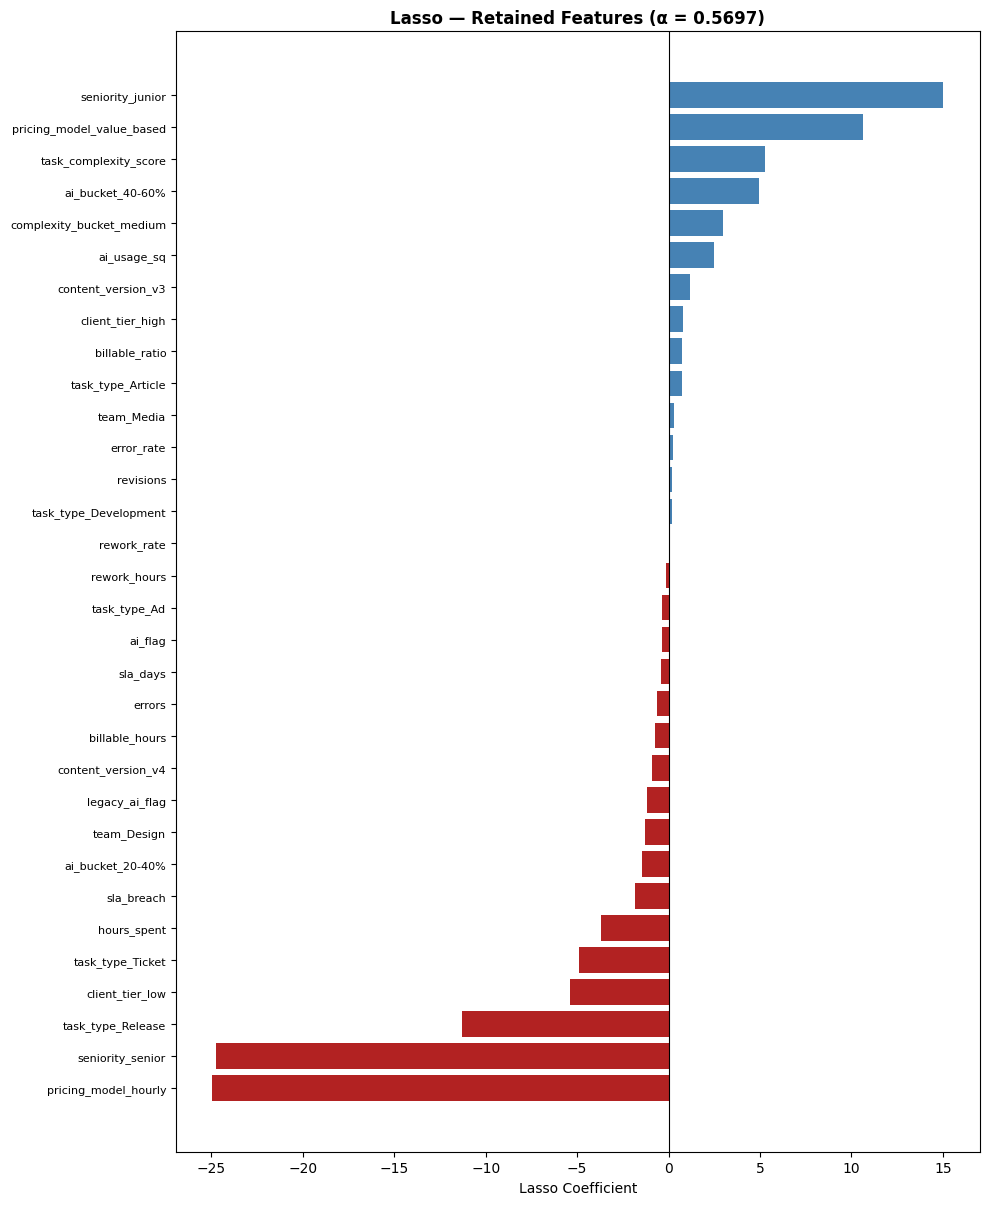

In [79]:
# ── Lasso feature selection ────────────────────────────────────────────────
preprocessor_full = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe = Pipeline([
    ('pre', preprocessor_full),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe.fit(X_train, y_train)

all_names_full = get_feature_names(lasso_pipe.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef = lasso_pipe.named_steps['lasso'].coef_
best_alpha = lasso_pipe.named_steps['lasso'].alpha_

nonzero_mask = lasso_coef != 0
retained_names = [n for n, m in zip(all_names_full, nonzero_mask) if m]
zeroed_names = [n for n, m in zip(all_names_full, nonzero_mask) if not m]
retained_coefs = lasso_coef[nonzero_mask]

display(pd.DataFrame({
    'Metric': [
        'Best alpha (LassoCV)',
        'Features retained',
        'Features zeroed out',
    ],
    'Value': [
        f'{best_alpha:.4f}',
        f'{nonzero_mask.sum()} / {len(lasso_coef)}',
        f'{len(zeroed_names)} / {len(lasso_coef)}',
    ]
}))

# ── Coefficient plot ───────────────────────────────────────────────────────
sort_idx = np.argsort(retained_coefs)
s_names = [retained_names[i] for i in sort_idx]
s_coefs = retained_coefs[sort_idx]
s_colors = ['steelblue' if c > 0 else 'firebrick' for c in s_coefs]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names) * 0.38)))
ax.barh(range(len(s_names)), s_coefs, color=s_colors)
ax.set_yticks(range(len(s_names)))
ax.set_yticklabels(s_names, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso — Retained Features (α = {best_alpha:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s1.png', dpi=150, bbox_inches='tight')

### Step 2: Linear Regression on Lasso-Selected Features

Lasso returns non-zero coefficients for a subset of the encoded (one-hot) features. Those encoded features are mapped back to their original column names so that the preprocessor can be rebuilt on the reduced feature set. Linear Regression is then fitted on this reduced set.

- **R², MAE, RMSE** on the held-out test set measure predictive accuracy on unseen data
- **5-fold CV R²** on the training set gives a less optimistic estimate of generalisation

The coefficient plot shows the 10 strongest positive and 10 strongest negative associations with `profit_margin`.

In [81]:
# ── Map encoded features back to original column names ────────────────────
retained_base = set()
for name in retained_names:
    if name in NUM_FEATURES:
        retained_base.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base.add(cat)
                break

lr_num  = [f for f in NUM_FEATURES if f in retained_base]
lr_cat  = [f for f in CAT_FEATURES if f in retained_base]
lr_cols = lr_num + lr_cat

display(pd.DataFrame({
    'Type'   : ['Numeric'] * len(lr_num) + ['Categorical'] * len(lr_cat),
    'Feature': lr_num + lr_cat,
}))

# ── Fit Linear Regression on reduced feature set ───────────────────────────
preprocessor_lr = build_preprocessor(lr_num, lr_cat)
lr_pipe = Pipeline([
    ('pre', preprocessor_lr),
    ('lr',  LinearRegression()),
])
lr_pipe.fit(X_train[lr_cols], y_train)

lr_r2, lr_mae, lr_rmse, lr_cv_r2 = eval_model(
    lr_pipe, X_train[lr_cols], X_test[lr_cols], y_train, y_test
)

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²'],
    'Value' : [f'{lr_r2:.4f}', f'{lr_mae:.2f}', f'{lr_rmse:.2f}', f'{lr_cv_r2:.4f}'],
}).set_index('Metric'))

,Type,Feature
0,Numeric,task_complexity_score
1,Numeric,sla_days
2,Numeric,sla_breach
3,Numeric,hours_spent
4,Numeric,billable_hours
5,Numeric,revisions
6,Numeric,errors
7,Numeric,rework_hours
8,Numeric,legacy_ai_flag
9,Numeric,ai_flag


,Value
Metric,
Test R²,0.2048
Test MAE (pp),32.06
Test RMSE (pp),48.55
5-fold CV R²,0.0832


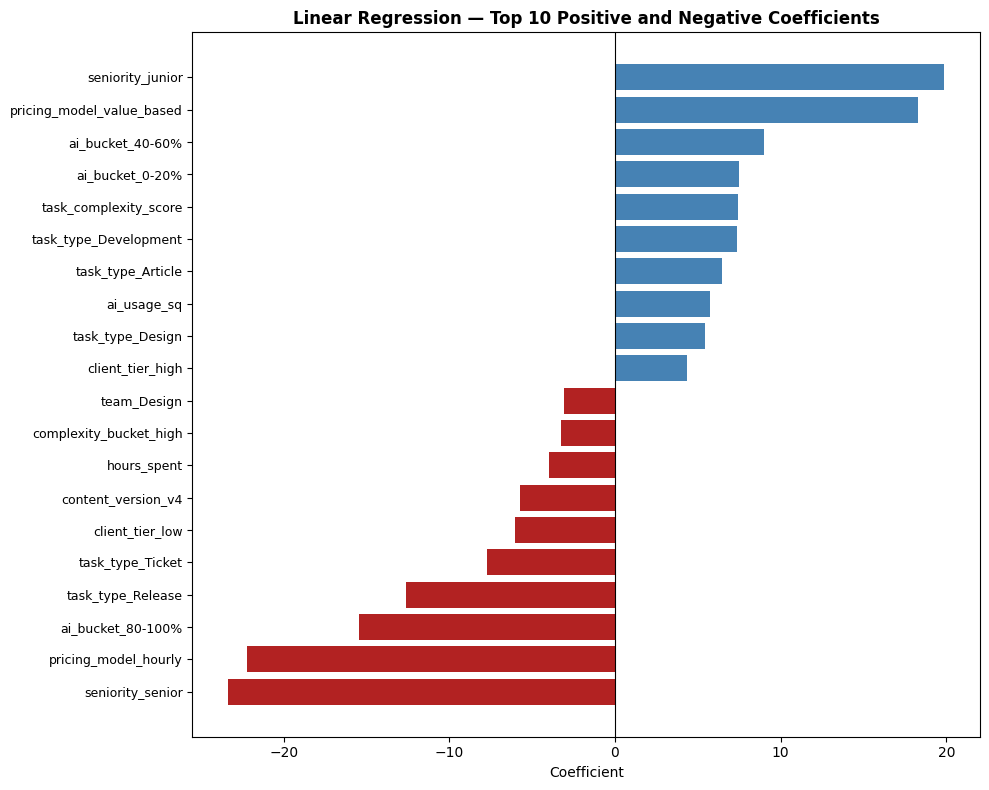

In [82]:
# ── Coefficient plot ───────────────────────────────────────────────────────
lr_feature_names = get_feature_names(lr_pipe.named_steps['pre'], lr_num, lr_cat)
coef_df = pd.DataFrame({
    'feature': lr_feature_names,
    'coef'   : lr_pipe.named_steps['lr'].coef_,
})
plot_df = pd.concat([
    coef_df.nlargest(10, 'coef'),
    coef_df.nsmallest(10, 'coef'),
]).drop_duplicates().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'firebrick' for c in plot_df['coef']]
ax.barh(range(len(plot_df)), plot_df['coef'].values, color=colors)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'].values, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Linear Regression — Top 10 Positive and Negative Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lr_coefficients_s1.png', dpi=150, bbox_inches='tight')

### Step 3: Random Forest with Grid Search

Random Forest is trained on the **full candidate feature set**, not the Lasso-reduced set. Including all candidates allows the forest to capture interactions and non-linearities that Lasso penalises to zero under L1 regularisation.

`GridSearchCV` with 5-fold CV searches over the following hyperparameters:

- `n_estimators`: 100, 200, 300
- `max_depth`: 4, 6, 8, or unconstrained
- `min_samples_leaf`: 10, 20, 40

The `min_samples_leaf` grid guards against overfitting to small leaf nodes on a dataset of this size. The best CV R² from `GridSearchCV` is reported alongside the test R² — the former is the more conservative estimate of generalisation performance.

In [84]:
# ── Random Forest with GridSearchCV ───────────────────────────────────────
preprocessor_rf = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_leaf': [10, 20, 40],
}

rf_pipe_base = Pipeline([
    ('pre', preprocessor_rf),
    ('rf',  RandomForestRegressor(random_state=42)),
])

rf_gs = GridSearchCV(
    rf_pipe_base, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
rf_r2, rf_mae, rf_rmse, rf_cv_r2 = eval_model(
    best_rf, X_train, X_test, y_train, y_test
)
rf_cv_r2 = rf_gs.best_score_


In [85]:
best_params = rf_gs.best_params_
display(pd.DataFrame({
    'Parameter': ['n_estimators', 'max_depth', 'min_samples_leaf'],
    'Value'    : [
        best_params['rf__n_estimators'],
        best_params['rf__max_depth'],
        best_params['rf__min_samples_leaf'],
    ],
}).set_index('Parameter'))

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Linear Regression'],
    'Value' : [
        f'{rf_r2:.4f}',
        f'{rf_mae:.2f}',
        f'{rf_rmse:.2f}',
        f'{rf_cv_r2:.4f}',
        f'{rf_r2 - lr_r2:+.4f}',
    ],
}).set_index('Metric'))

,Value
Parameter,
n_estimators,300.0
max_depth,NaN
min_samples_leaf,10.0


,Value
Metric,
Test R²,0.3445
Test MAE (pp),27.64
Test RMSE (pp),44.08
5-fold CV R²,0.1843
Δ R² vs Linear Regression,+0.1397


### Model Comparison

The two models operate on different feature sets by design. Linear Regression uses only the features Lasso retained; Random Forest uses the full candidate set. This makes the comparison more informative than a head-to-head on identical inputs: the R² gap captures both the gain from non-linearity and the gain from features Lasso penalised to zero under its linear-additive assumption.

If Random Forest substantially outperforms Linear Regression, two explanations are possible: the data contains non-linear structure, or there are predictive features that Lasso discarded. The SHAP analysis below helps distinguish between them.

,Test R2,Test MAE (pp),Test RMSE (pp),5-fold CV R2
Model,,,,
Linear Regression,0.2048,32.0612,48.5523,0.0832
Random Forest,0.3445,27.6358,44.0819,0.1843


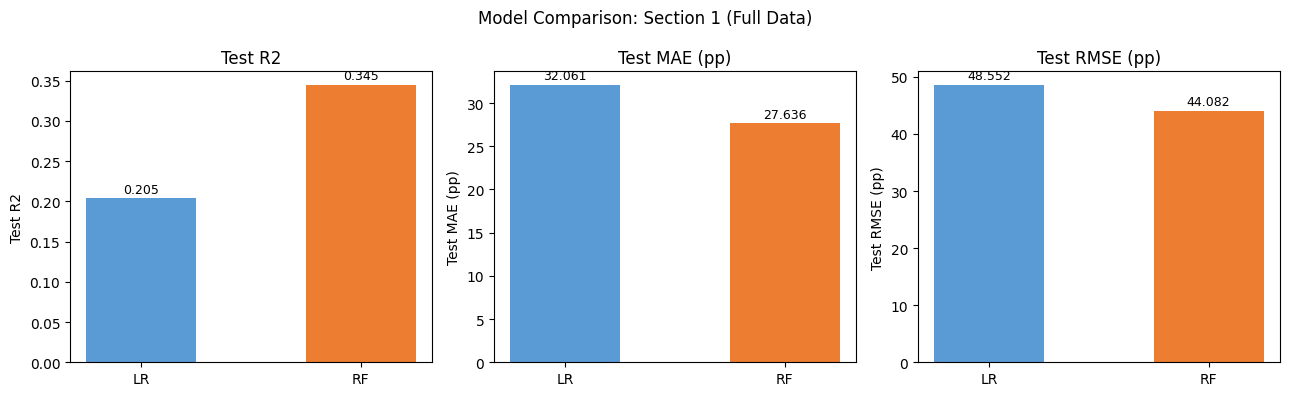

In [55]:
s1_results = pd.DataFrame({
    'Model':          ['Linear Regression', 'Random Forest'],
    'Test R2':        [lr_r2,   rf_r2],
    'Test MAE (pp)':  [lr_mae,  rf_mae],
    'Test RMSE (pp)': [lr_rmse, rf_rmse],
    '5-fold CV R2':   [lr_cv_r2, rf_cv_r2],
})
display(s1_results.set_index('Model').round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['Test R2', 'Test MAE (pp)', 'Test RMSE (pp)']
for ax, metric in zip(axes, metrics):
    vals = s1_results[metric].values
    bars = ax.bar(['LR', 'RF'], vals, color=['#5b9bd5', '#ed7d31'], width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric)
    ax.set_ylabel(metric)
plt.suptitle('Model Comparison: Section 1 (Full Data)', fontsize=12)
plt.tight_layout()
plt.savefig('images/model_comparison_s1.png', dpi=150, bbox_inches='tight')
plt.show()


## SHAP Analysis: Random Forest (Section 1)

`shap.TreeExplainer` computes exact Shapley values for tree-based models.
The beeswarm plot shows the 15 features with the highest mean absolute SHAP value.
Each point is one test observation; colour encodes the feature value (red = high, blue = low).

The dependence plot for `ai_usage_pct` shows how the model's output shifts across
the range of AI usage, with point colour indicating the value of the feature
that SHAP identifies as most interactive with `ai_usage_pct`.

After the plots, a cross-check against the Lasso-selected features identifies
which predictors are supported by both methods.


### SHAP Analysis: Interpretation

The beeswarm plot and ranking table identify **pricing model, billable ratio, and seniority** as the dominant drivers of `profit_margin`, collectively accounting for the three highest mean absolute SHAP values. `ai_usage_pct` ranks 14th out of all features, confirming that AI usage intensity has a statistically detectable but relatively modest direct contribution to margin in the context of the full feature set.

**Key findings by feature:**

- **`pricing_model_hourly`** (rank 1, mean |SHAP| = 15.23): the single strongest predictor. Tasks billed on an hourly basis are associated with large negative SHAP values, meaning hourly pricing systematically compresses `profit_margin`. This is structurally expected: under hourly billing, productivity gains from AI reduce billable hours and therefore revenue, rather than expanding margin;
- **`billable_ratio`** (rank 2, mean |SHAP| = 12.49): tasks where a higher share of hours are billable show higher margins, as expected;
- **`seniority_senior` / `seniority_junior`** (ranks 3 and 5): senior workers are associated with higher margins, junior workers with lower ones, likely reflecting differences in task complexity, revision rates, and billing rates;
- **`hours_spent`** (rank 4): longer tasks are associated with lower margins, consistent with cost overruns on fixed-price or value-based contracts;
- **`ai_usage_pct`** (rank 14, mean |SHAP| = 0.70): a positive directional effect is visible in the dependence plot. SHAP values for `ai_usage_pct` rise as AI usage increases, confirming the threshold finding from the EDA. However, the magnitude is small relative to structural factors such as pricing model and seniority

**Dependence plot for `ai_usage_pct`:** the SHAP values for `ai_usage_pct` show a clear upward trend from roughly −1 to +2 on the x-axis, indicating that higher AI usage is associated with a progressively more positive contribution to predicted margin. The interaction colour (pink = hourly pricing, blue = non-hourly) reveals that the positive effect is more pronounced for non-hourly tasks. Under hourly billing, in fact, the margin benefit of AI usage is substantially attenuated, reinforcing the pricing model interaction identified in the EDA.

ai_usage_pct SHAP rank: 14 / 57


,Feature,Mean |SHAP|
1,pricing_model_hourly,15.2346
2,billable_ratio,12.4893
3,seniority_senior,10.1451
4,hours_spent,7.1973
5,seniority_junior,3.5964
6,task_complexity_score,3.1197
7,task_type_Ad,1.3961
8,billable_hours,1.3137
9,seniority_mid,1.1302
10,rework_rate,1.0913


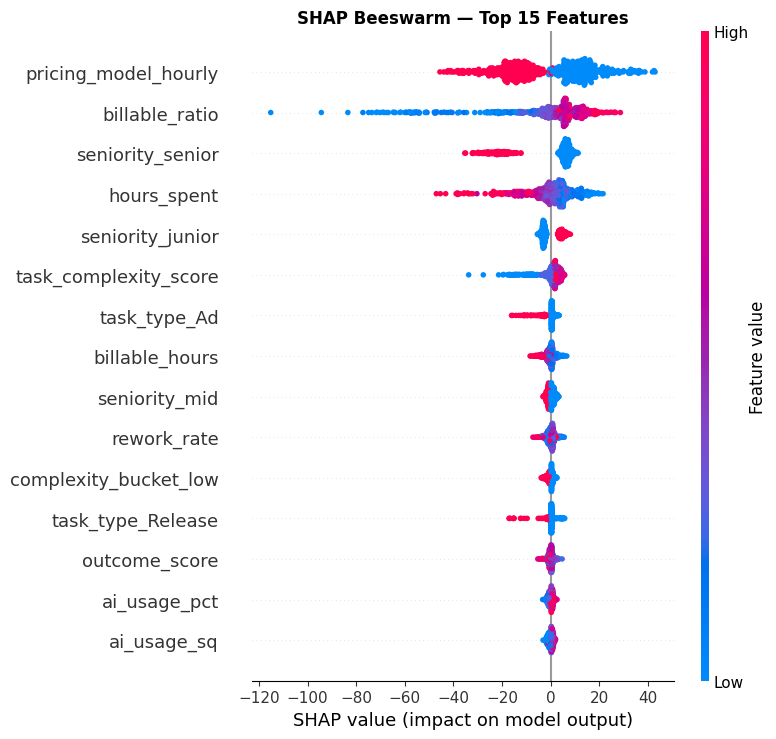

<Figure size 800x500 with 0 Axes>

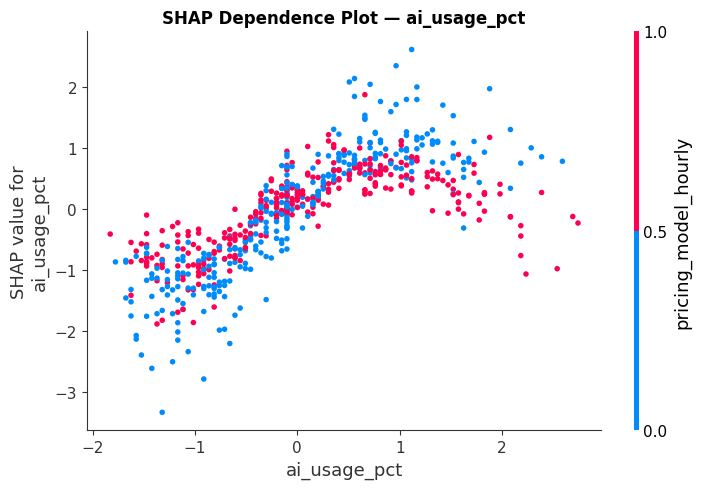

In [ ]:
# ── SHAP values ────────────────────────────────────────────────────────────
X_test_tr = best_rf.named_steps['pre'].transform(X_test)
rf_feature_names = get_feature_names(best_rf.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer = shap.TreeExplainer(best_rf.named_steps['rf'])
shap_values = explainer.shap_values(X_test_tr)

mean_abs = np.abs(shap_values).mean(axis=0)
shap_rank_df = (
    pd.DataFrame({'Feature': rf_feature_names, 'Mean |SHAP|': mean_abs})
    .sort_values('Mean |SHAP|', ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.index += 1

ai_rank = shap_rank_df[shap_rank_df['Feature'] == 'ai_usage_pct'].index[0]
print(f'ai_usage_pct SHAP rank: {ai_rank} / {len(rf_feature_names)}')
display(shap_rank_df.head(15).round(4))

# ── Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_tr,
    feature_names=rf_feature_names,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Dependence plot ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values, X_test_tr,
    feature_names=rf_feature_names, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s1.png', dpi=150, bbox_inches='tight')

### SHAP vs Lasso Cross-Check

Lasso retained features based on a linear, regularised model. SHAP ranks features by their average marginal contribution to the Random Forest's predictions, capturing both linear and non-linear effects.
The cross-check confirms strong agreement between the two methods:
- **11 out of 15 SHAP top features were also retained by Lasso**, indicating that the dominant margin drivers are robust across both linear and non-linear assumptions.
- The four features in SHAP top 15 but zeroed by Lasso (`ai_usage_pct`, `outcome_score`, `complexity_bucket_low`, and `seniority_mid`) contribute to the Random Forest's predictions through non-linear or interaction effects that L1 penalisation cannot capture. Notably, `ai_usage_pct` falls into this category, which is consistent with the threshold pattern identified in the EDA: its relationship with `profit_margin` is non-linear and therefore invisible to a linear selector.
- The 21 features retained by Lasso but ranking outside the SHAP top 15 carry redundant linear signal that the forest distributes across correlated features: they are not meaningless, but their individual marginal contribution is small once the dominant predictors are accounted for.

In [87]:
# ── SHAP vs Lasso Cross-Check ──────────────────────────────────────────────
shap_top15 = set(shap_rank_df.head(15)['Feature'])
lasso_retained = set(retained_names)

both = shap_top15 & lasso_retained
shap_only = shap_top15 - lasso_retained
lasso_only = lasso_retained - shap_top15

cross_check = pd.DataFrame({
    'Feature': sorted(both) + sorted(shap_only) + sorted(lasso_only),
    'SHAP Top 15': ['✓'] * len(both) + ['✓'] * len(shap_only) + [''] * len(lasso_only),
    'Lasso Retained': ['✓'] * len(both) + [''] * len(shap_only) + ['✓'] * len(lasso_only),
    'Category': ['High rank in both'] * len(both) +
                     ['High SHAP, zeroed by Lasso'] * len(shap_only) +
                     ['Retained by Lasso, low SHAP'] * len(lasso_only),
})

display(cross_check.set_index('Feature'))

,SHAP Top 15,Lasso Retained,Category
Feature,,,
ai_usage_sq,✓,✓,High rank in both
billable_hours,✓,✓,High rank in both
billable_ratio,✓,✓,High rank in both
hours_spent,✓,✓,High rank in both
pricing_model_hourly,✓,✓,High rank in both
rework_rate,✓,✓,High rank in both
seniority_junior,✓,✓,High rank in both
seniority_senior,✓,✓,High rank in both
task_complexity_score,✓,✓,High rank in both


### Log-transformed Features

Several numeric features in this dataset have strongly right-skewed distributions: a small number of tasks with very high hours, rework, or revenue pull the tail far from the median. Applying `np.log1p` compresses the long tail, brings the distribution closer to symmetric, and improves the linearity assumption that OLS and Lasso rely on.

The transformation is applied only to features where the interpretation is preserved after compression: `hours_spent`, `billable_hours`, `rework_hours`, `revenue`, `cost`, `errors`, `revisions`. All other features — including engineered ratios, boolean flags, and categorical variables — are left unchanged. The target variable `profit_margin` is not transformed, as it contains negative values.

> **Note:** Random Forest makes no linearity assumption and is invariant to monotonic feature transformations. Any difference in RF performance between the two sections is expected to be negligible. The log transform is a diagnostic for the linear models only — RF is included purely as a methodological control.

In [88]:
# ── Log-transform selected features ───────────────────────────────────────
LOG_COLS = ['hours_spent', 'billable_hours', 'rework_hours', 'revenue', 'cost',
            'errors', 'revisions']

df_log = df_productivity.copy()
df_log[LOG_COLS] = np.log1p(df_log[LOG_COLS])

### Visual Verification of Log-transform Effect

Before fitting models on `df_log`, we visually confirm that the transformation achieved its intended effect on each feature's distribution. The statistical justification for log-transforming, reducing right skew, must be verified empirically, not simply assumed. A feature that was already approximately symmetric would not benefit from the transform and could be left in its original scale without loss.

The grid below shows, for each transformed feature, the original distribution (left, blue) and the log-transformed distribution (right, green). Skewness values are reported in each subplot title.

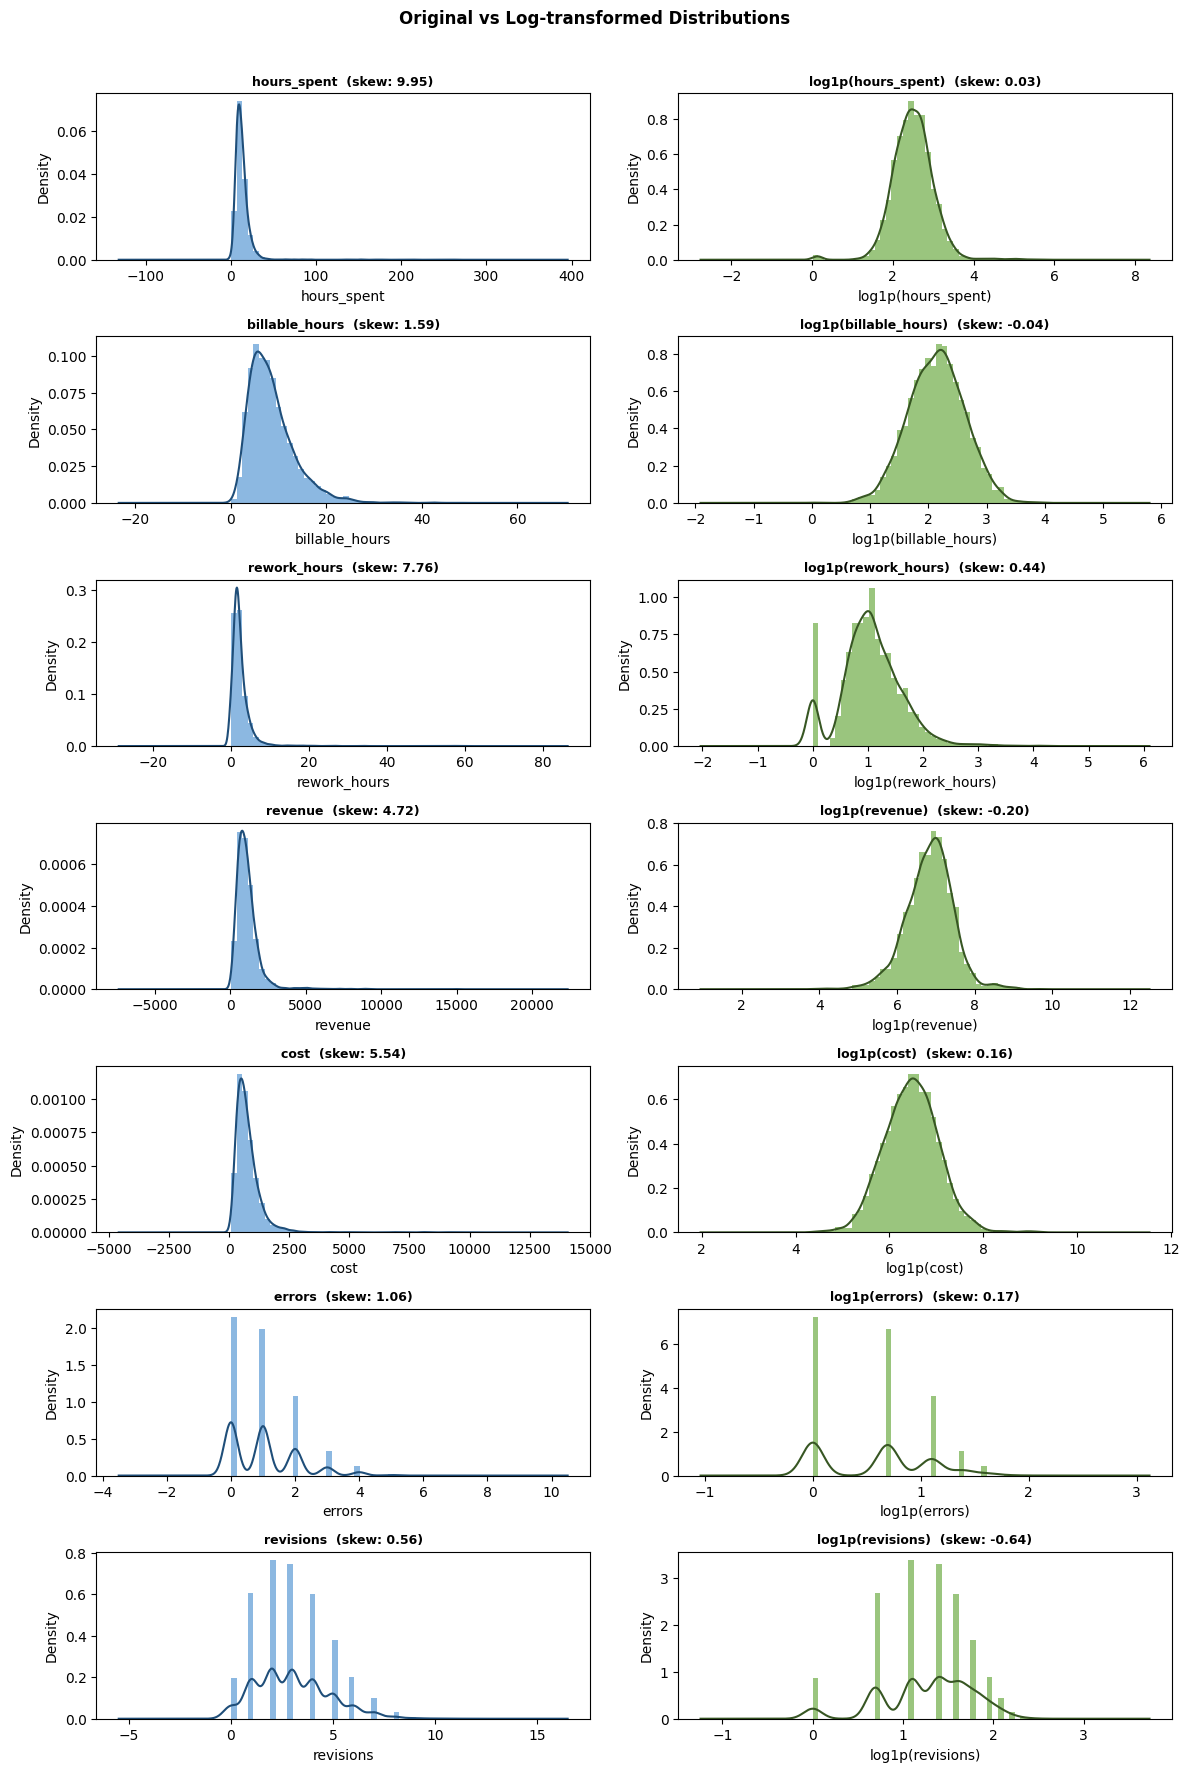

In [89]:
# ── Distribution comparison: original vs log-transformed ──────────────────
fig, axes = plt.subplots(len(LOG_COLS), 2, figsize=(12, len(LOG_COLS) * 2.5))

for row, col in enumerate(LOG_COLS):
    skew_orig = df_productivity[col].skew()
    skew_log  = df_log[col].skew()

    # ── Original ───────────────────────────────────────────────────────────
    ax_orig = axes[row, 0]
    ax_orig.hist(df_productivity[col].dropna(), bins=40, color='#5b9bd5', alpha=0.7, density=True)
    df_productivity[col].dropna().plot.kde(ax=ax_orig, color='#1f4e79', linewidth=1.5)
    ax_orig.set_title(f'{col}  (skew: {skew_orig:.2f})', fontsize=9, fontweight='bold')
    ax_orig.set_xlabel(col)
    ax_orig.set_ylabel('Density')

    # ── Log-transformed ────────────────────────────────────────────────────
    ax_log = axes[row, 1]
    ax_log.hist(df_log[col].dropna(), bins=40, color='#70ad47', alpha=0.7, density=True)
    df_log[col].dropna().plot.kde(ax=ax_log, color='#375623', linewidth=1.5)
    ax_log.set_title(f'log1p({col})  (skew: {skew_log:.2f})', fontsize=9, fontweight='bold')
    ax_log.set_xlabel(f'log1p({col})')
    ax_log.set_ylabel('Density')

plt.suptitle('Original vs Log-transformed Distributions', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/log_distribution_comparison.png', dpi=150, bbox_inches='tight')

### Train / Test Split

The same 80/20 split is applied to `df_log`.

In [ ]:
# ── Train / test split ─────────────────────────────────────────────────────
X_log = df_log[CANDIDATE_FEATURES]
y_log = df_log[TARGET]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

display(pd.DataFrame({
    'Set'  : ['Train', 'Test'],
    'Rows' : [X_train_log.shape[0], X_test_log.shape[0]],
    'Share': ['80%', '20%'],
}))

,Set,Rows,Share
0,Train,2560,80%
1,Test,640,20%


### Step 1: Lasso Feature Selection + Linear Regression

`LassoCV` selects the feature subset on the log-transformed training data. If skew correction improves the linear signal, we expect Lasso to retain more features or assign larger coefficients to the transformed numeric variables, and LR test R² to increase relative to Section 1.
The log-transformed Lasso selects **28 features** at α = 0.6109, retaining the same core predictors identified in Section 1. The performance metrics confirm the expected improvement: LR test R² rises from 0.2048 to **0.2487** (+0.0439), with a corresponding reduction in MAE from 32.06 to 30.65 pp.

The coefficient plots are consistent with Section 1 in terms of directionality:

- **`pricing_model_hourly`** and **`seniority_senior`** remain the strongest negative predictors: hourly billing and senior worker assignment are both associated with lower margins, the former because AI productivity gains reduce billable hours under this pricing structure;
- **`seniority_junior`**, **`billable_hours`**, and **`pricing_model_value_based`** are the strongest positive predictors, with `seniority_junior` showing the largest positive coefficient in both sections;
- **`hours_spent`** retains a large negative coefficient, confirming that longer tasks compress margins regardless of AI usage;

One notable difference from Section 1 is that `ai_bucket_40-60%` and `ai_bucket_0-20%` now appear among the top positive coefficients in the LR plot, suggesting that after log-transforming the scale-dominated features, the AI usage signal becomes more visible to the linear model. This is consistent with the SHAP finding that `ai_usage_pct` was contributing through non-linear effects that OLS previously could not isolate.

,Value
Metric,
Best alpha (LassoCV),0.6109
Features retained,27 / 57
Features zeroed out,30 / 57


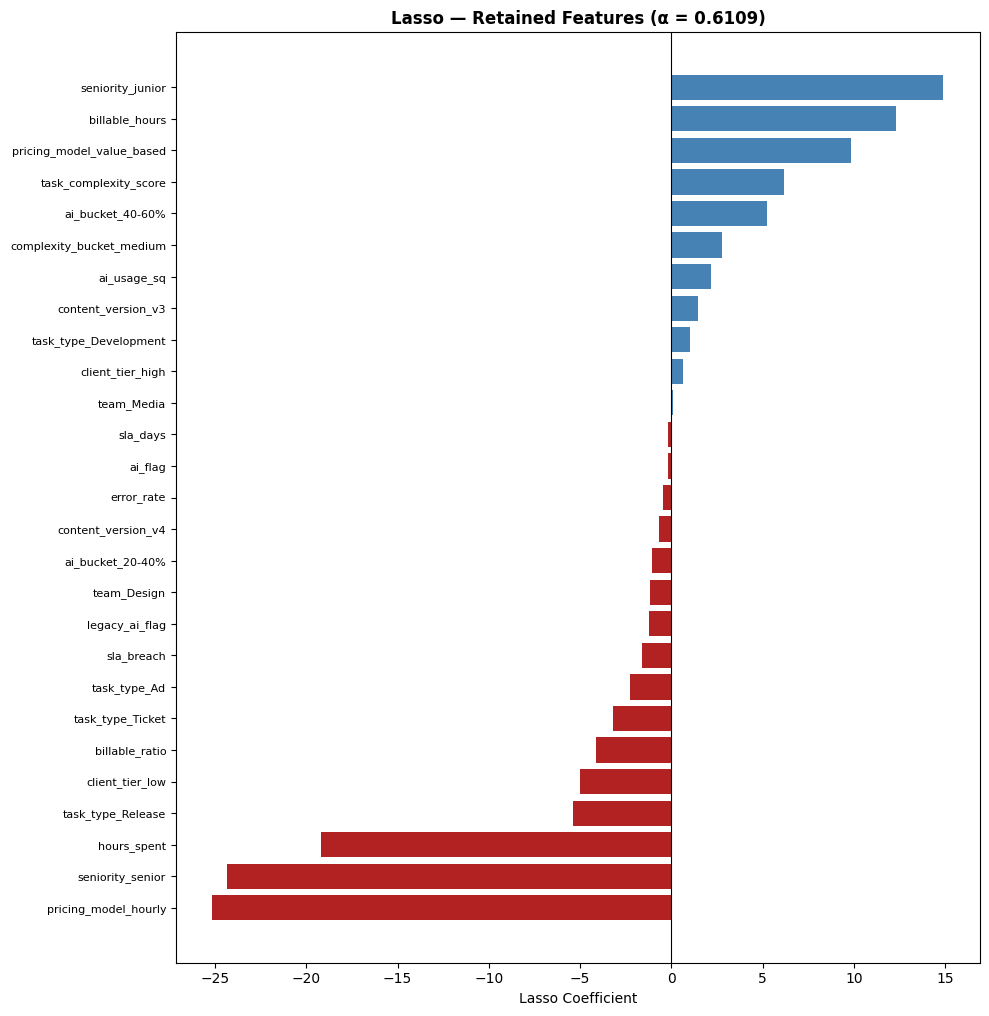

In [ ]:
# ── Lasso feature selection ────────────────────────────────────────────────
preprocessor_full_log = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe_log = Pipeline([
    ('pre',   preprocessor_full_log),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe_log.fit(X_train_log, y_train_log)

all_names_log = get_feature_names(lasso_pipe_log.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef_log = lasso_pipe_log.named_steps['lasso'].coef_
best_alpha_log = lasso_pipe_log.named_steps['lasso'].alpha_
nonzero_mask_log = lasso_coef_log != 0
retained_names_log = [n for n, m in zip(all_names_log, nonzero_mask_log) if m]
retained_coefs_log = lasso_coef_log[nonzero_mask_log]

display(pd.DataFrame({
    'Metric': ['Best alpha (LassoCV)', 'Features retained', 'Features zeroed out'],
    'Value' : [
        f'{best_alpha_log:.4f}',
        f'{nonzero_mask_log.sum()} / {len(lasso_coef_log)}',
        f'{(~nonzero_mask_log).sum()} / {len(lasso_coef_log)}',
    ],
}).set_index('Metric'))

# ── Lasso coefficient plot ─────────────────────────────────────────────────
sort_idx_log = np.argsort(retained_coefs_log)
s_names_log = [retained_names_log[i] for i in sort_idx_log]
s_coefs_log = retained_coefs_log[sort_idx_log]
s_colors_log = ['steelblue' if c > 0 else 'firebrick' for c in s_coefs_log]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names_log) * 0.38)))
ax.barh(range(len(s_names_log)), s_coefs_log, color=s_colors_log)
ax.set_yticks(range(len(s_names_log)))
ax.set_yticklabels(s_names_log, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso — Retained Features (α = {best_alpha_log:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s2.png', dpi=150, bbox_inches='tight')

,Type,Feature
0,Numeric,task_complexity_score
1,Numeric,sla_days
2,Numeric,sla_breach
3,Numeric,hours_spent
4,Numeric,billable_hours
5,Numeric,legacy_ai_flag
6,Numeric,ai_flag
7,Numeric,error_rate
8,Numeric,billable_ratio
9,Numeric,ai_usage_sq


,Value
Metric,
Test R²,0.2487
Test MAE (pp),30.65
Test RMSE (pp),47.19
5-fold CV R²,0.1069
Δ R² vs Section 1 LR,+0.0439


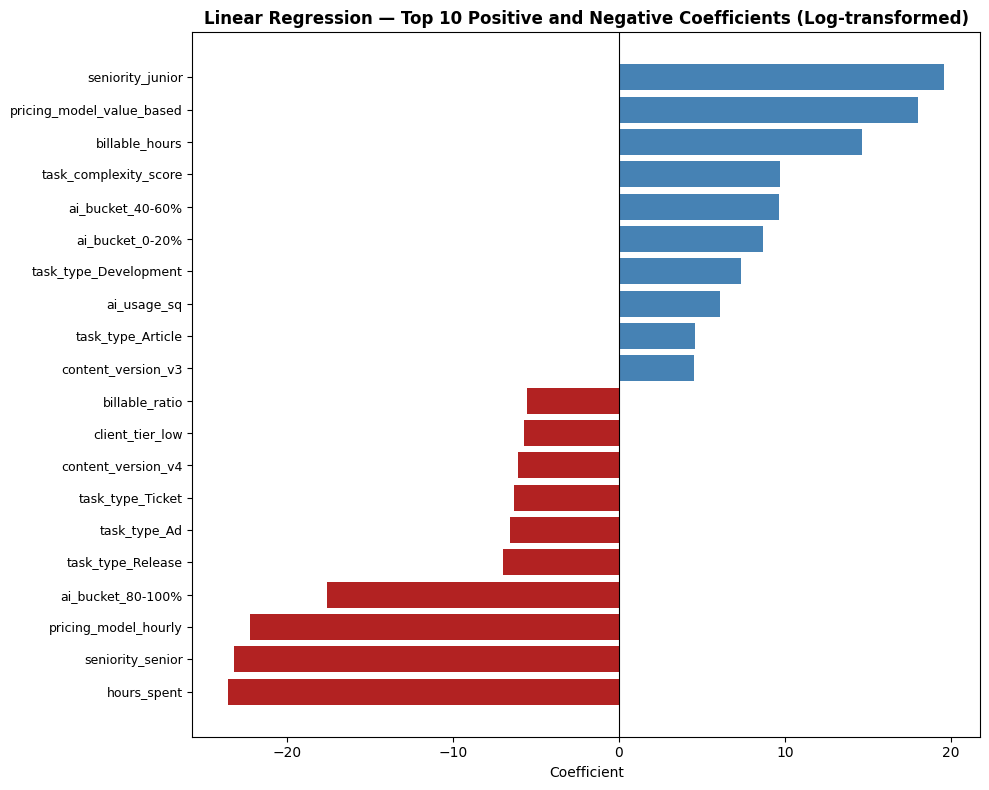

In [ ]:
# ── LR on Lasso-selected features ─────────────────────────────────────────
retained_base_log = set()
for name in retained_names_log:
    if name in NUM_FEATURES:
        retained_base_log.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base_log.add(cat)
                break

lr_num_log = [f for f in NUM_FEATURES if f in retained_base_log]
lr_cat_log  = [f for f in CAT_FEATURES if f in retained_base_log]
lr_cols_log = lr_num_log + lr_cat_log

display(pd.DataFrame({
    'Type'   : ['Numeric'] * len(lr_num_log) + ['Categorical'] * len(lr_cat_log),
    'Feature': lr_num_log + lr_cat_log,
}))

preprocessor_lr_log = build_preprocessor(lr_num_log, lr_cat_log)
lr_pipe_log = Pipeline([
    ('pre', preprocessor_lr_log),
    ('lr',  LinearRegression()),
])
lr_pipe_log.fit(X_train_log[lr_cols_log], y_train_log)

lr_r2_log, lr_mae_log, lr_rmse_log, lr_cv_r2_log = eval_model(
    lr_pipe_log, X_train_log[lr_cols_log], X_test_log[lr_cols_log], y_train_log, y_test_log
)

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Section 1 LR'],
    'Value' : [
        f'{lr_r2_log:.4f}',
        f'{lr_mae_log:.2f}',
        f'{lr_rmse_log:.2f}',
        f'{lr_cv_r2_log:.4f}',
        f'{lr_r2_log - lr_r2:+.4f}',
    ],
}).set_index('Metric'))

# ── LR coefficient plot ────────────────────────────────────────────────────
lr_feature_names_log = get_feature_names(lr_pipe_log.named_steps['pre'], lr_num_log, lr_cat_log)
coef_df_log = pd.DataFrame({
    'feature': lr_feature_names_log,
    'coef'   : lr_pipe_log.named_steps['lr'].coef_,
})
plot_df_log = pd.concat([
    coef_df_log.nlargest(10, 'coef'),
    coef_df_log.nsmallest(10, 'coef'),
]).drop_duplicates().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors_log = ['steelblue' if c > 0 else 'firebrick' for c in plot_df_log['coef']]
ax.barh(range(len(plot_df_log)), plot_df_log['coef'].values, color=colors_log)
ax.set_yticks(range(len(plot_df_log)))
ax.set_yticklabels(plot_df_log['feature'].values, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Linear Regression — Top 10 Positive and Negative Coefficients (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lr_coefficients_s2.png', dpi=150, bbox_inches='tight')

### Step 2: Random Forest on Log-transformed Features

Random Forest splits are based on rank order rather than absolute values, so any monotonic transformation — including `log1p` — leaves the optimal split thresholds and resulting predictions unchanged in expectation. The RF is included here not to improve performance but to **confirm the invariance empirically**: the test R² should be within rounding noise of the Section 1 result (0.3445), serving as a built-in methodological control for the experiment.

The Random Forest on the log-transformed dataset produces a test R² of **0.3445**, identical to Section 1. MAE and RMSE are likewise unchanged at 27.64 pp and 44.08 pp respectively. The best hyperparameters are also consistent with Section 1: 300 estimators, unconstrained depth, and a minimum leaf size of 10.

This result is the expected outcome and serves as empirical confirmation of the invariance property: `log1p` is a monotonic transformation, so the rank ordering of any feature's values is preserved and the forest finds identical split boundaries. The zero delta provides a clean methodological control: any difference in overall model performance between Section 1 and Section 2 is attributable entirely to the log transform's effect on the **linear models**, not to any change in the data's underlying structure.

In [ ]:
# ── Random Forest on log-transformed features (GridSearchCV) ──────────────
preprocessor_rf_log = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_pipe_base_log = Pipeline([
    ('pre', preprocessor_rf_log),
    ('rf',  RandomForestRegressor(random_state=42)),
])

rf_gs_log = GridSearchCV(
    rf_pipe_base_log, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs_log.fit(X_train_log, y_train_log)

best_rf_log  = rf_gs_log.best_estimator_
rf_r2_log, rf_mae_log, rf_rmse_log, rf_cv_r2_log = eval_model(
    best_rf_log, X_train_log, X_test_log, y_train_log, y_test_log
)
rf_cv_r2_log = rf_gs_log.best_score_

Best params: {'rf__max_depth': None, 'rf__min_samples_leaf': 10, 'rf__n_estimators': 300}
RF (log)  Test R2: 0.3445  MAE: 27.64 pp  RMSE: 44.08 pp  CV R2: 0.1843


In [90]:
best_params_log = rf_gs_log.best_params_
display(pd.DataFrame({
    'Parameter': ['n_estimators', 'max_depth', 'min_samples_leaf'],
    'Value'    : [
        best_params_log['rf__n_estimators'],
        best_params_log['rf__max_depth'],
        best_params_log['rf__min_samples_leaf'],
    ],
}).set_index('Parameter'))

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Section 1 RF'],
    'Value' : [
        f'{rf_r2_log:.4f}',
        f'{rf_mae_log:.2f}',
        f'{rf_rmse_log:.2f}',
        f'{rf_cv_r2_log:.4f}',
        f'{rf_r2_log - rf_r2:+.4f}',
    ],
}).set_index('Metric'))

,Value
Parameter,
n_estimators,300.0
max_depth,NaN
min_samples_leaf,10.0


,Value
Metric,
Test R²,0.3445
Test MAE (pp),27.64
Test RMSE (pp),44.08
5-fold CV R²,0.1843
Δ R² vs Section 1 RF,-0.0000


## SHAP Analysis: Random Forest (Section 2)

`shap.TreeExplainer` is applied to the Random Forest fitted on `df_log` using the same
procedure as Section 1. The beeswarm and dependence plots are regenerated on the
log-transformed test set.

Because Random Forest is invariant to monotonic feature transformations, we expect the
feature importance rankings to be stable between Section 1 and Section 2. Large rank
changes would indicate that a feature's apparent importance in Section 1 was an artefact
of scale rather than a genuine relationship.

ai_usage_pct SHAP rank (Section 2): 14 / 57
Top 15 features by mean |SHAP| (Section 2):


,feature,mean_abs_shap
0,pricing_model_hourly,15.234132
1,billable_ratio,12.488721
2,seniority_senior,10.117616
3,hours_spent,7.197021
4,seniority_junior,3.658228
5,task_complexity_score,3.124824
6,task_type_Ad,1.396070
7,billable_hours,1.314501
8,rework_rate,1.091614
9,seniority_mid,1.061869


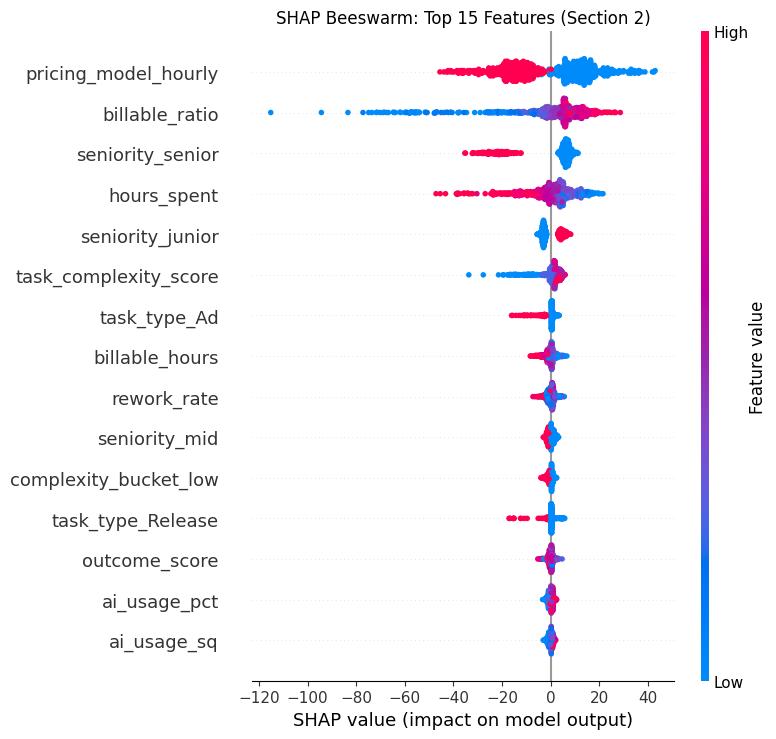

<Figure size 800x500 with 0 Axes>

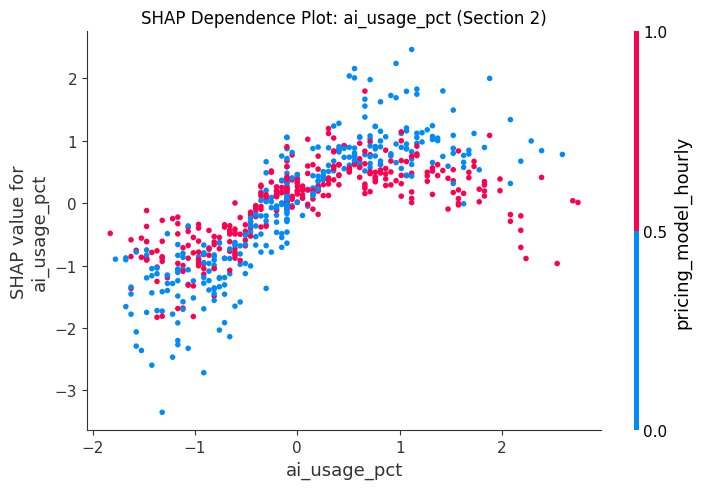

In [ ]:
X_test_tr_log        = best_rf_log.named_steps['pre'].transform(X_test_log)
rf_feature_names_log = get_feature_names(best_rf_log.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer_log    = shap.TreeExplainer(best_rf_log.named_steps['rf'])
shap_values_log  = explainer_log.shap_values(X_test_tr_log)

mean_abs_log     = np.abs(shap_values_log).mean(axis=0)
shap_rank_df_log = pd.DataFrame({'feature': rf_feature_names_log, 'mean_abs_shap': mean_abs_log})
shap_rank_df_log = shap_rank_df_log.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
ai_rank_log = shap_rank_df_log[shap_rank_df_log['feature'] == 'ai_usage_pct'].index[0] + 1
print(f'ai_usage_pct SHAP rank (Section 2): {ai_rank_log} / {len(rf_feature_names_log)}')
print('Top 15 features by mean |SHAP| (Section 2):')
display(shap_rank_df_log.head(15))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features (Section 2)')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s2.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct (Section 2)')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s2.png', dpi=150, bbox_inches='tight')

### SHAP Analysis: Random Forest (Log-transformed)

`shap.TreeExplainer` is applied to the Random Forest fitted on `df_log` using the same procedure as Section 1. The beeswarm and dependence plots are regenerated on the log-transformed test set.

Because Random Forest is invariant to monotonic feature transformations, we expect the feature importance rankings to be **stable** between Section 1 and Section 2. Large rank changes would indicate that a feature's apparent importance in Section 1 was an artefact of scale rather than a genuine relationship — a finding that would call the Section 1 SHAP interpretation into question.

### Findings
The SHAP rankings on the log-transformed dataset are **identical to Section 1** across all 15 positions: same features, same order, and mean |SHAP| values matching to four decimal places. 
`pricing_model_hourly` (15.23), `billable_ratio` (12.49), and `seniority_senior` (10.15) remain the top three predictors, and `ai_usage_pct` holds rank 14 at 0.70.

This result directly confirms the invariance property: the Random Forest learned the same relationships from the log-transformed data as from the original data, because the rank ordering of all feature values is preserved under `log1p`. No feature's importance shifted as a result of the transformation, ruling out scale artefacts as a confound in the Section 1 SHAP interpretation.

The dependence plot for `ai_usage_pct` is likewise unchanged: SHAP values rise progressively with AI usage intensity, and the pricing model interaction (pink = hourly, blue = non-hourly) shows the same pattern where the margin benefit of higher AI adoption is attenuated under hourly billing, while more pronounced under fixed or value-based contracts. The stability of this plot across both sections confirms that the positive AI-margin relationship identified in the EDA is a genuine signal, not an artefact of the original feature scale.

ai_usage_pct SHAP rank: 14 / 57


,Feature,Mean |SHAP|
1,pricing_model_hourly,15.2320
2,billable_ratio,12.4893
3,seniority_senior,10.1460
4,hours_spent,7.1981
5,seniority_junior,3.5966
6,task_complexity_score,3.1206
7,task_type_Ad,1.3961
8,billable_hours,1.3137
9,seniority_mid,1.1301
10,rework_rate,1.0911


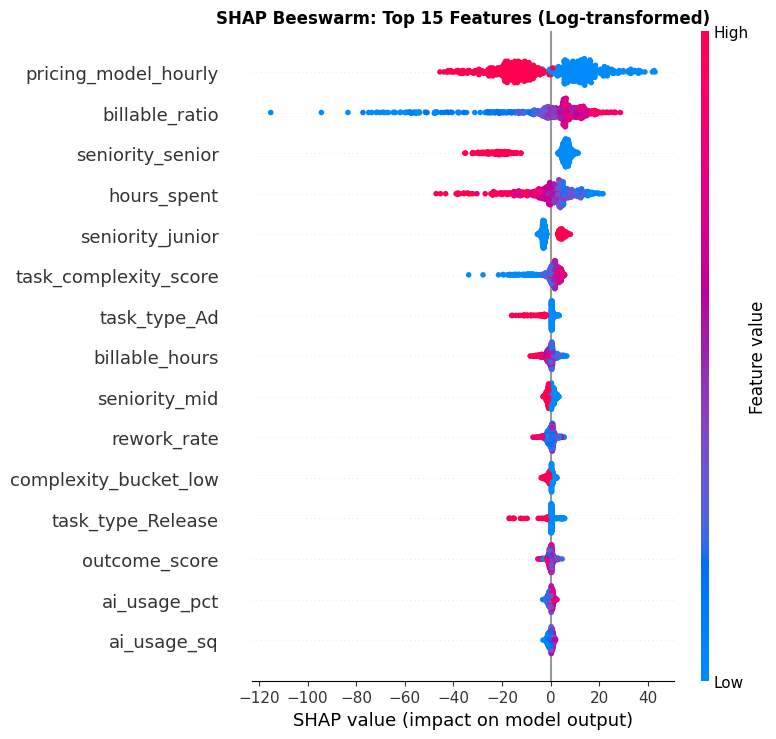

<Figure size 800x500 with 0 Axes>

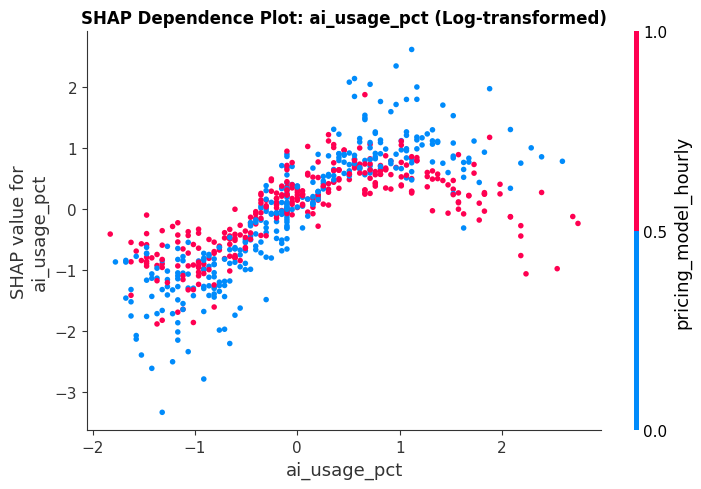

In [ ]:
# ── SHAP values (log-transformed) ─────────────────────────────────────────
X_test_tr_log = best_rf_log.named_steps['pre'].transform(X_test_log)
rf_feature_names_log = get_feature_names(best_rf_log.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer_log = shap.TreeExplainer(best_rf_log.named_steps['rf'])
shap_values_log = explainer_log.shap_values(X_test_tr_log)

mean_abs_log = np.abs(shap_values_log).mean(axis=0)
shap_rank_df_log = (
    pd.DataFrame({'Feature': rf_feature_names_log, 'Mean |SHAP|': mean_abs_log})
    .sort_values('Mean |SHAP|', ascending=False)
    .reset_index(drop=True)
)
shap_rank_df_log.index += 1

ai_rank_log = shap_rank_df_log[shap_rank_df_log['Feature'] == 'ai_usage_pct'].index[0]
print(f'ai_usage_pct SHAP rank: {ai_rank_log} / {len(rf_feature_names_log)}')
display(shap_rank_df_log.head(15).round(4))

# ── Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s2.png', dpi=150, bbox_inches='tight')

# ── Dependence plot ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s2.png', dpi=150, bbox_inches='tight')

### Model Comparison: Section 1 vs Section 2

The table below places all four model configurations side by side. 
- A meaningful improvement in LR R² confirms that right-skew was a binding constraint on OLS;
- A negligible change in RF R² confirms the invariance expectation;
- The delta columns make the differences explicit.

### Interpretation

The log transform produced a LR R² gain of **+0.0439** (from 0.2048 to 0.2487), with a corresponding MAE reduction of 1.41 pp (from 32.06 to 30.65). This confirms that right-skewed feature distributions were a binding constraint on OLS: the extreme values in `hours_spent`, `rework_hours`, `revenue`, and `cost` were pulling the least-squares solution away from the underlying linear signal, and compressing those tails via `log1p` partially restores it.

The RF R² delta is exactly **0.0000** (0.3445 in both sections), with MAE and RMSE likewise unchanged to two decimal places. This is the methodological validation of the experiment: because Random Forest is theoretically invariant to monotonic feature transformations, a zero delta confirms the RF is acting as a built-in control. The LR improvement can therefore be attributed entirely to the distributional correction, not to any data artefact or information leak introduced during the transformation.

The remaining gap between LR (0.2487) and RF (0.3445) after the transform shows that non-linear interactions persist in the data that OLS cannot capture regardless of input scale. Log-transforming closes part of the gap but not all of it: the feature-margin relationship is non-linear beyond the scale correction, and a flexible model is needed to capture the full signal available in the dataset.

In [ ]:
# ── Comparison table ───────────────────────────────────────────────────────
comparison_log = pd.DataFrame({
    'Dataset'       : ['Base', 'Base', 'Log-transformed', 'Log-transformed'],
    'Model'         : ['Linear Regression', 'Random Forest',
                       'Linear Regression', 'Random Forest'],
    'Test R²'       : [lr_r2,   rf_r2,   lr_r2_log,   rf_r2_log],
    'Test MAE (pp)' : [lr_mae,  rf_mae,  lr_mae_log,  rf_mae_log],
    'Test RMSE (pp)': [lr_rmse, rf_rmse, lr_rmse_log, rf_rmse_log],
})
display(comparison_log.set_index(['Dataset', 'Model']).round(4))

delta_log = pd.DataFrame({
    'Model'                  : ['Linear Regression', 'Random Forest'],
    'Δ R² (Log − Base)'      : [lr_r2_log  - lr_r2,  rf_r2_log  - rf_r2],
    'Δ MAE (Log − Base) (pp)': [lr_mae_log - lr_mae, rf_mae_log - rf_mae],
})
display(delta_log.set_index('Model').round(4))

Test R²  Test MAE (pp)  Test RMSE (pp)
Dataset         Model                                                    
Base            Linear Regression   0.2048        32.0612         48.5523
                Random Forest       0.3445        27.6398         44.0835
Log-transformed Linear Regression   0.2487        30.6535         47.1942
                Random Forest       0.3445        27.6425         44.0842

,Δ R² (Log − Base),Δ MAE (Log − Base) (pp)
Model,,
Linear Regression,0.0439,-1.4076
Random Forest,-0.0000,0.0027


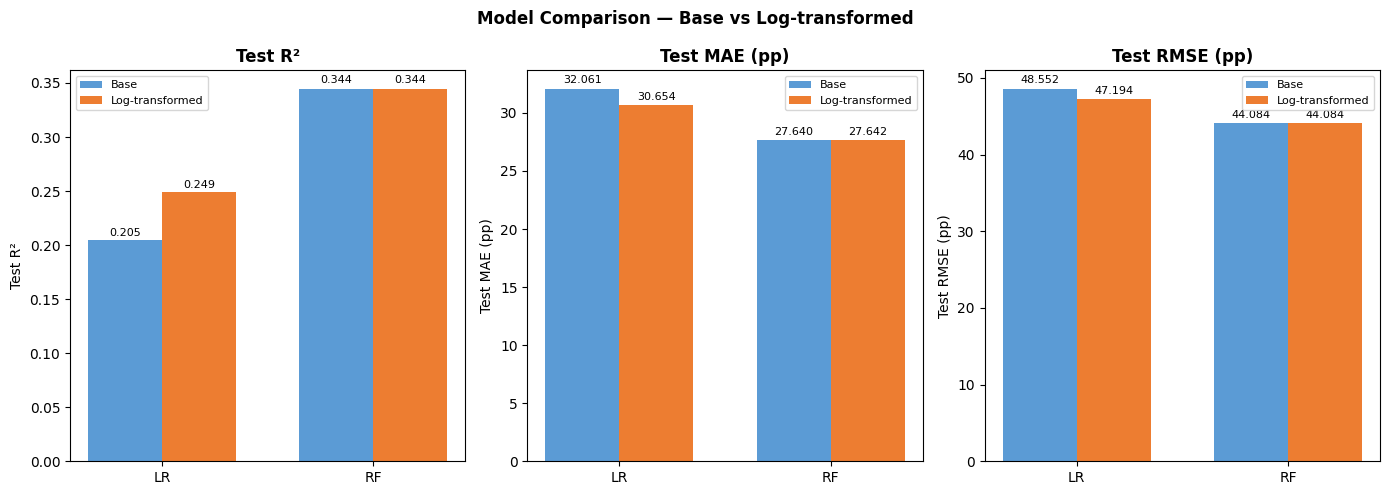

In [ ]:
# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_map_log = {
    'Test R²': ([lr_r2, rf_r2], [lr_r2_log, rf_r2_log]),
    'Test MAE (pp)': ([lr_mae,  rf_mae], [lr_mae_log,  rf_mae_log]),
    'Test RMSE (pp)': ([lr_rmse, rf_rmse], [lr_rmse_log, rf_rmse_log]),
}
x = np.arange(2)
w = 0.35

for ax, (metric, (base_vals, log_vals)) in zip(axes, metrics_map_log.items()):
    b1 = ax.bar(x - w/2, base_vals, w, label='Base', color='#5b9bd5')
    b2 = ax.bar(x + w/2, log_vals,  w, label='Log-transformed', color='#ed7d31')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF'])
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8
        )

plt.suptitle('Model Comparison — Base vs Log-transformed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison_s2.png', dpi=150, bbox_inches='tight')

## `Business Narrative`

### Three Key Insights

**1. AI adoption intensity is the signal, not AI presence.**
Tasks split simply into "used AI" vs "did not use AI" show no statistically significant difference in profit margin, confirmed by both Welch's t-test and Mann-Whitney U. The signal only becomes visible above roughly 40-60% AI usage intensity, where margins rise consistently with each bucket. Teams operating at 80–100% AI intensity show median margins approximately 28 percentage points higher than those below 20%. Presence without intensity is not adoption.

**2. Pricing model is the primary structural moderator and it interacts directly with AI.**
`pricing_model_hourly` is the single strongest predictor of `profit_margin` in both the SHAP analysis (mean |SHAP| = 15.23) and the Lasso selection. Under hourly billing, productivity gains from AI reduce billable hours rather than expanding marginL: the value flows to the client, not the business. Fixed-price and value-based contracts capture the same productivity gain as profit. The SHAP dependence plot for `ai_usage_pct` confirms this interaction directly: the positive AI-margin effect is substantially attenuated for hourly-billed tasks and amplified for non-hourly ones.

**3. The feature-margin relationship is real but partially non-linear.**
After correcting for right-skewed features via `log1p`, Linear Regression explains 24.9% of margin variance, with a meaningful gain of +4.4 percentage points over the base model. The Random Forest reaches 34.5% regardless of the transformation, confirming that non-linear interactions persist beyond scale correction. The remaining ~65% of variance is driven by factors outside the dataset: client pricing power, competitive dynamics, and individual worker skill. Aggregate margin improvement from AI is measurable; individual task outcomes will always carry substantial noise.

### Concrete Business Decision

Two levers need to move together for AI adoption to convert into profit. First, teams currently operating below 40% AI usage intensity should be prioritised for structured adoption support: the data shows they are systematically leaving margin on the table relative to high-intensity adopters. 

Second, any adoption push applied to hourly-billed teams must be paired with a contract renegotiation: shifting repeatable, high-AI tasks to fixed-price or retainer structures is the mechanism through which the productivity gain converts to margin rather than being absorbed as a billing reduction. Adopting AI without repricing is, in the current data, revenue-neutral at best.